In [1]:
import cv2

In [2]:
from deepface import DeepFace as df
print("DeepFace OK")

26-09-27 01:23:26 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.



I0000 00:00:1790452406.912478 1188721 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


DeepFace OK


I0000 00:00:1790452407.861882 1188721 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
img = cv2.imread('happy_boy.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [4]:
import matplotlib.pyplot as plt

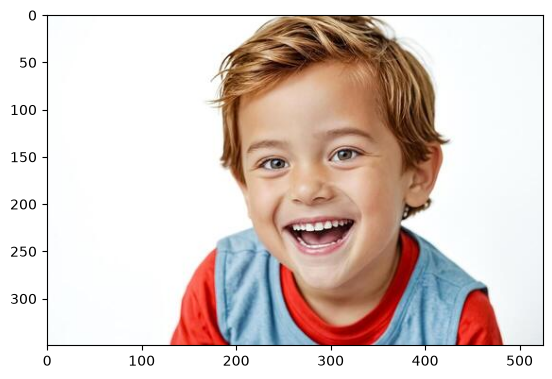

In [5]:
plt.imshow(img)

In [6]:
predictions = df.analyze(img)

Action: race: 100%|██████████| 4/4 [00:02<00:00,  1.46it/s]   


In [7]:
predictions

[{'emotion': {'angry': np.float32(8.016792e-09),
   'disgust': np.float32(2.9885543e-18),
   'fear': np.float32(1.153415e-07),
   'happy': np.float32(98.7804),
   'sad': np.float32(1.0762053e-06),
   'surprise': np.float32(1.2190495),
   'neutral': np.float32(0.000541677)},
  'dominant_emotion': 'happy',
  'region': {'x': 171,
   'y': 66,
   'w': 211,
   'h': 211,
   'left_eye': (311, 148),
   'right_eye': (239, 158)},
  'face_confidence': 0.88,
  'age': 17,
  'gender': {'Woman': np.float32(0.5030633), 'Man': np.float32(99.49694)},
  'dominant_gender': 'Man',
  'race': {'asian': np.float32(0.23879926),
   'indian': np.float32(0.1535352),
   'black': np.float32(0.0064345384),
   'white': np.float32(69.91991),
   'middle eastern': np.float32(9.728516),
   'latino hispanic': np.float32(19.95281)},
  'dominant_race': 'white'}]

In [8]:
type(predictions)

list

In [9]:
predictions = dict(predictions[0])

In [10]:
predictions['dominant_emotion']

'happy'

In [11]:
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [12]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = faceCascade.detectMultiScale(gray,1.1,4)

for(x,y,w,h) in faces:
    cv2.rectangle(img,(x,y), (x+w,y+h), (0,255,0), 2)

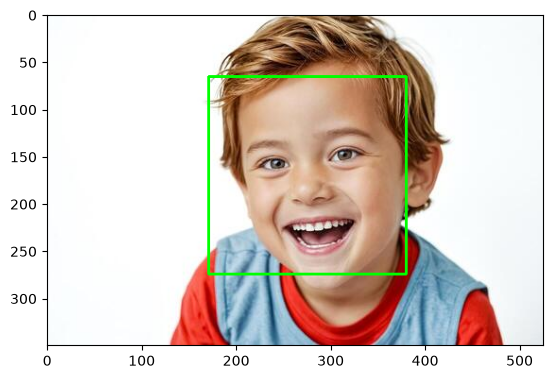

In [13]:
plt.imshow(img)

In [14]:
font = cv2.FONT_HERSHEY_SIMPLEX

cv2.putText(img,
            predictions['dominant_emotion'].upper(),
            (0,50),
            font,1,
            (255,0,0),
            2,
            cv2.LINE_4);

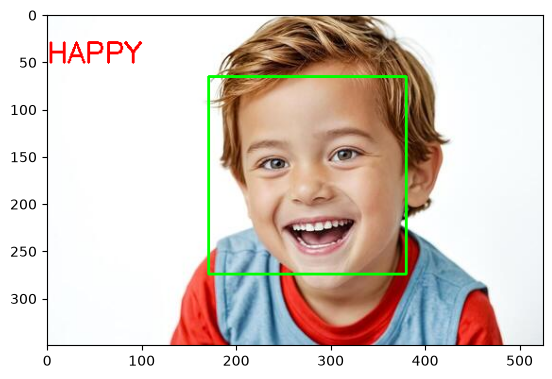

In [15]:
plt.imshow(img)

In [16]:
img1 = cv2.imread('sad_woman.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

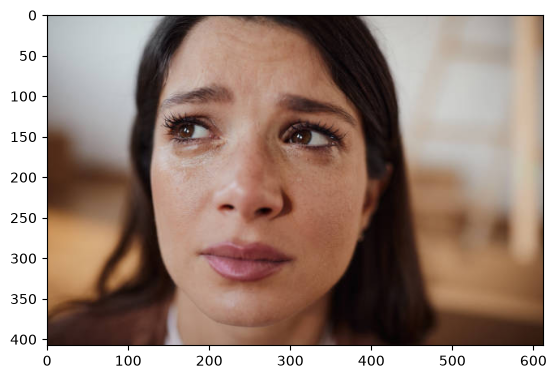

In [17]:
plt.imshow(img1)

In [18]:
predictions = df.analyze(img1)

Action: race: 100%|██████████| 4/4 [00:00<00:00, 12.67it/s]  


In [19]:
predictions

[{'emotion': {'angry': np.float32(5.790442),
   'disgust': np.float32(0.00021120675),
   'fear': np.float32(10.998105),
   'happy': np.float32(9.422915e-05),
   'sad': np.float32(79.66647),
   'surprise': np.float32(0.0032877778),
   'neutral': np.float32(3.5413888)},
  'dominant_emotion': 'sad',
  'region': {'x': 74,
   'y': 4,
   'w': 358,
   'h': 358,
   'left_eye': (314, 150),
   'right_eye': (174, 141)},
  'face_confidence': 0.91,
  'age': 27,
  'gender': {'Woman': np.float32(82.9511), 'Man': np.float32(17.048895)},
  'dominant_gender': 'Woman',
  'race': {'asian': np.float32(50.347775),
   'indian': np.float32(9.259565),
   'black': np.float32(2.8134172),
   'white': np.float32(5.337708),
   'middle eastern': np.float32(2.6804996),
   'latino hispanic': np.float32(29.561039)},
  'dominant_race': 'asian'}]

In [20]:
predictions = dict(predictions[0])

In [21]:
gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
faces = faceCascade.detectMultiScale(gray,1.1,4)

for(x,y,w,h) in faces:
    cv2.rectangle(img1,(x,y), (x+w,y+h), (0,255,0), 2)

font = cv2.FONT_HERSHEY_SIMPLEX

cv2.putText(img1,
            predictions['dominant_emotion'].upper(),
            (0,50),
            font,1,
            (255,0,0),
            2,
            cv2.LINE_4);

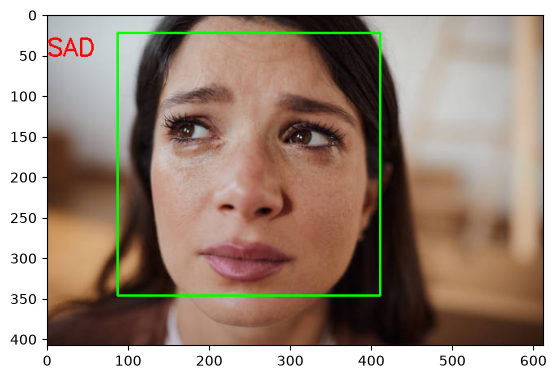

In [22]:
plt.imshow(img1)

# Real time video Demo for Face Emotion Recognition

In [ ]:
import cv2

cap = cv2.VideoCapture(0, cv2.CAP_V4L2)

if not cap.isOpened():
    raise IOError("Cannot open webcam")

while True:
    ret, frame = cap.read()

    if not ret:
        print("Failed to read frame")
        break

    result = df.analyze(
        frame,
        actions=['emotion'],
        enforce_detection=False
    )

    if result:
        emotion = result[0]['dominant_emotion'].upper()

        cv2.putText(
            frame,
            emotion,
            (50, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255, 0, 0),
            2,
            cv2.LINE_4
        )

    cv2.imshow("Demo video", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/moosa/deepface-env/lib/python3.13/site-packages/cv2/qt/plugins"
